# Model state

This notebook plots the model state. Specifically:

- SST
- barotropic streamfunction
- zonal average temperature
- zonal average temperature gradient
- overturning circulation
- zonal mean velocity

If not otherwise specified I will plot the average of the monthly data.
The experiments were run for one year.

There is also a plot of the overturning in density-latitude space.

In [2]:
tub_output_dir = "/g/data/e14/jb2381/anu-tub/outputs"
if pwd() != tub_output_dir 
    cd(tub_output_dir)
end
include("plotting.jl")

  Activating project at `/g/data/e14/jb2381/anu-tub/outputs`
[ Info: Plotting and analysis environment setup!
┌ Info: Experiments in the catalogue are:
│        - zstar-PPMH3
│        - hycom-default-PPMH3
│        - hycom-dz3-PPMH3
│        Available data is:
│           - daily
│           - monthly
│           - monthlyz
│           - monthlyrho2
│           - static
└           - vertical coordinate


Set colourbar limits for all vairbales so they are the same across plots.

In [38]:
θcrange = (-2, 30)
dθcrange = (-0.2, 0.2)
ψbcrange = range(-30, 70, 30)
ucrange = (-0.05, 0.05)
ψocrange = range(-9, 9, 20)

-9.0:0.75:9.0

## zstar

The information is either going to have to be presented on a single figure or one for each model.
I am aiming to get something that looks good here and then think about how to present the comparison.

In [39]:
zs_monthly = catalogue["zstar-PPMH3"]["monthly"]
zs_monthlyrho2 = catalogue["zstar-PPMH3"]["monthlyrho2"]
zs_monthlyz = catalogue["zstar-PPMH3"]["monthlyz"]
zs_static = catalogue["zstar-PPMH3"]["static"]
zs_vc = catalogue["zstar-PPMH3"]["vc"]

zs_crs = get_geo_coords(zs_static, zs_vc)

ds = NCDataset(zs_monthlyz, maskingvalue = NaN)

zs_sst = mean(ds["thetao"][:, :, 1, :], dims = 4)[:, :, 1, 1]
zs_tzm = mean(nanmean(ds["thetao"][:, :, :, :], dims = 1), dims = 4)[1, :, :, 1]
zs_uzm = nanmean(ds["uo"][:, :, :, :], dims = (1, 4))
zs_uzm = dropdims(zs_uzm, dims = (1, 4))
zs_interface_height = interface_height(zs_monthly; timestamp = 12)

close(ds)

zs_ψb = barotropic_streamfunction(zs_monthly)

zs_layer, zs_ψo = overturning_circulation(zs_monthlyz, "z_l")

zs_dθ = dθ_dz(zs_monthly)
zs_dθ = dropdims(zs_dθ, dims = (1, 4))

nothing

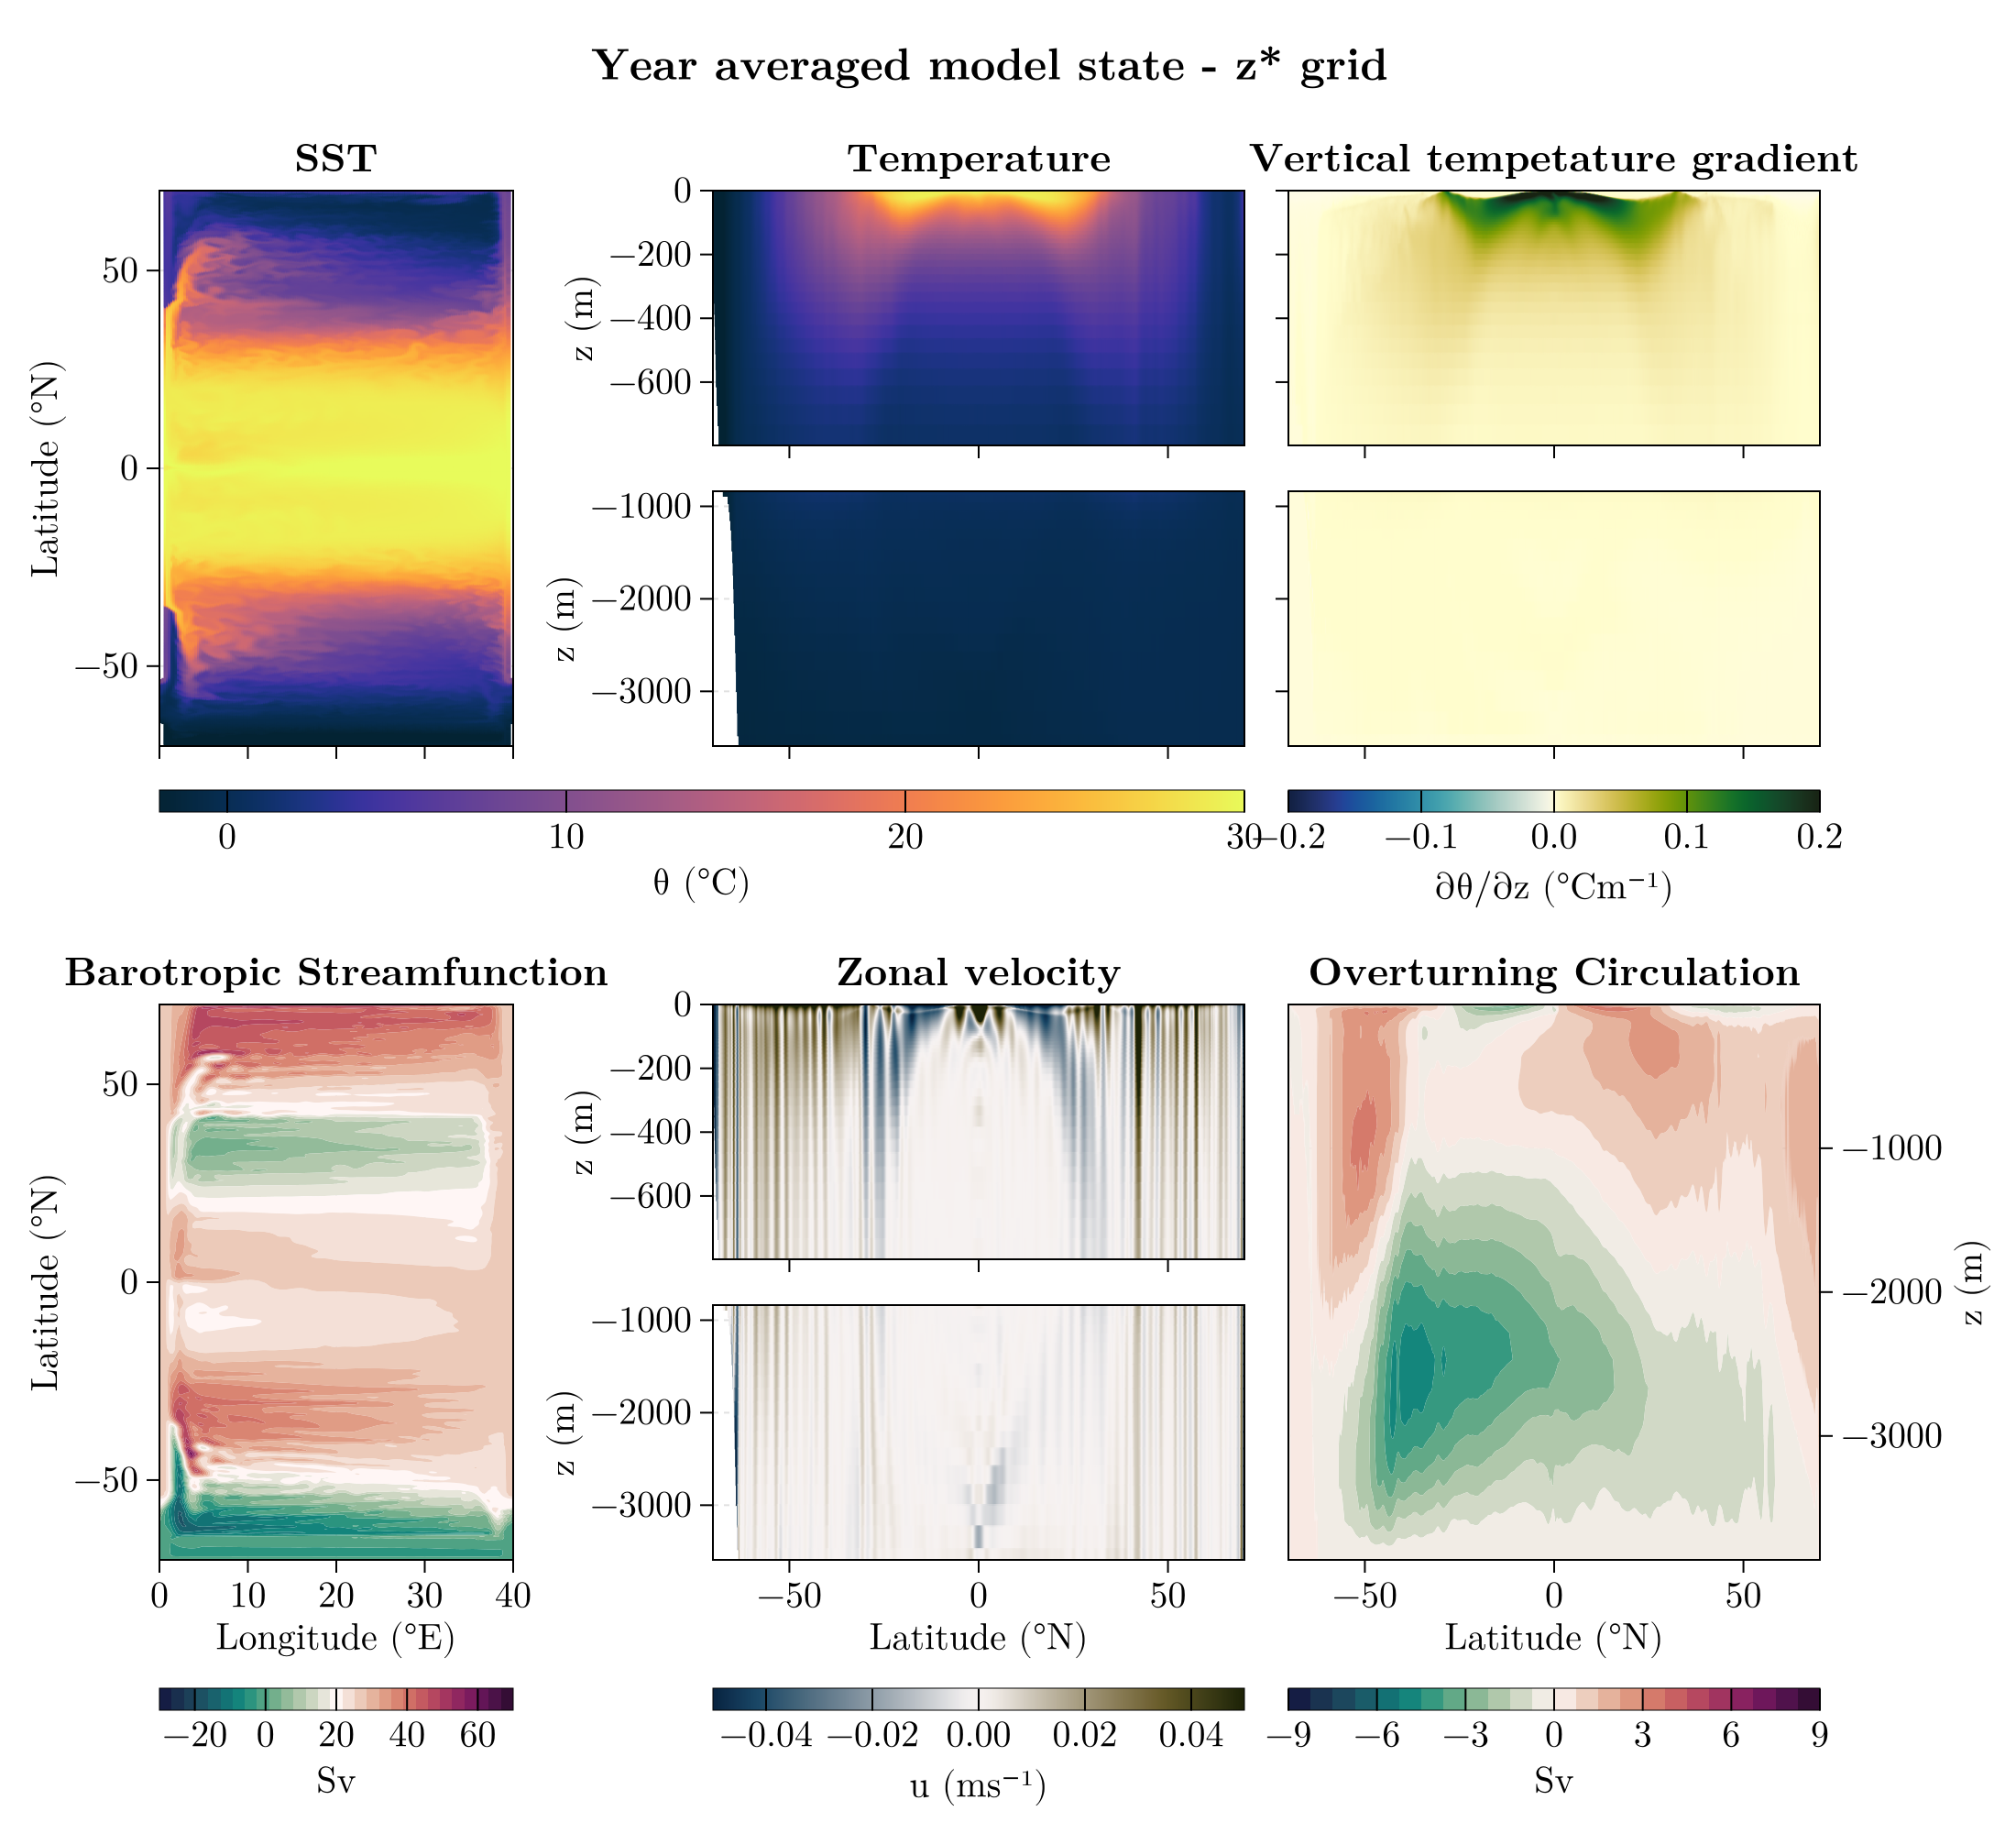

In [40]:
fig = Figure(size = (1100, 1000))

ax_sst = Axis(fig[1:2, 1], xlabel = "Longitude (°E)", ylabel = "Latitude (°N)", title = "SST")
hidexdecorations!(ax_sst, ticks = false)
hm = heatmap!(ax_sst, zs_crs.lonh, zs_crs.lath, zs_sst, colorrange = θcrange, colormap = :thermal)

top = 1:55
bot = top[end]+1:74

axtop = Axis(fig[1, 2], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Temperature")
hm = heatmap!(axtop, zs_crs.lath, zs_crs.zl[top], zs_tzm[:, top], colorrange = θcrange, colormap = :thermal)
axbot = Axis(fig[2, 2], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, zs_crs.lath, zs_crs.zl[bot], zs_tzm[:, bot], colorrange = θcrange, colormap = :thermal)
ylims!(axbot, zs_crs.zl[bot[end]], zs_crs.zl[bot[1]])
Colorbar(fig[3, 1:2], hm, vertical = false, flipaxis = false, label = "θ (°C)")

hidexdecorations!(axtop, ticks = false)
hidexdecorations!(axbot, ticks = false)

axtop = Axis(fig[1, 3], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Vertical tempetature gradient")
hm = heatmap!(axtop, zs_crs.lath, zs_crs.zl[top], zs_dθ[:, top]; colorrange = dθcrange, colormap = :delta)
axbot = Axis(fig[2, 3], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, zs_crs.lath, zs_crs.zl[bot], zs_dθ[:, bot]; colorrange = dθcrange, colormap = :delta)
ylims!(axbot, zs_crs.zl[bot[end]], zs_crs.zl[bot[1]])
Colorbar(fig[3, 3], hm, vertical = false, flipaxis = false, label = "∂θ/∂z (°Cm⁻¹)")

hidexdecorations!(axtop, ticks = false)
hidexdecorations!(axbot, ticks = false)
hideydecorations!(axtop, ticks = false)
hideydecorations!(axbot, ticks = false)

ax_ψb = Axis(fig[4:5, 1], xlabel = "Longitude (°E)", ylabel = "Latitude (°N)", title = "Barotropic Streamfunction")
xlims!(ax_ψb, zs_crs.lonq[1], zs_crs.lonq[end])
ylims!(ax_ψb, zs_crs.lath[1], zs_crs.lath[end])
cf = contourf!(ax_ψb, zs_crs.lonq, zs_crs.lath, zs_ψb[:, :, 1], colormap = :curl, levels = ψbcrange)
Colorbar(fig[6, 1], cf, vertical = false, flipaxis = false, label = "Sv")

# linkxaxes!(ax_sst, ax_ψb)

axtop = Axis(fig[4, 2], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Zonal velocity")
hm = heatmap!(axtop, zs_crs.lath, zs_crs.zl[top], zs_uzm[:, top]; colorrange = ucrange, colormap = :diff)
axbot = Axis(fig[5, 2], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, zs_crs.lath, zs_crs.zl[bot], zs_uzm[:, bot]; colorrange = ucrange, colormap = :diff)
ylims!(axbot, zs_crs.zl[bot[end]], zs_crs.zl[bot[1]])
Colorbar(fig[6, 2], hm, vertical = false, flipaxis = false, label = "u (ms⁻¹)")

hidexdecorations!(axtop, ticks = false)

# # depth-latitude
ax_ψo = Axis(fig[4:5, 3], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Overturning Circulation",
             yaxisposition = :right)
cf = contourf!(ax_ψo, zs_crs.latq, zs_crs.zl, zs_ψo[1, :, :, 1], colormap = :curl, levels = ψocrange)
Colorbar(fig[6, 3], cf, vertical = false, flipaxis = false, label = "Sv")
xlims!(ax_ψo, zs_crs.latq[1], zs_crs.latq[end])
ylims!(ax_ψo, zs_crs.zl[end], zs_crs.zl[1])

colsize!(fig.layout, 1, Relative(1/4))

Label(fig[0, :], "Year averaged model state - z* grid", fontsize = 24, font = :bold)

fig

In [5]:
save("modelstate_zstar.png", fig)

## HYCOM default

In [41]:
hy_d_key = "hycom-default-PPMH3"

hy_d_monthly = catalogue[hy_d_key]["monthly"]
hy_d_monthlyrho2 = catalogue[hy_d_key]["monthlyrho2"]
hy_d_monthlyz = catalogue[hy_d_key]["monthlyz"]
hy_d_static = catalogue[hy_d_key]["static"]
hy_d_vc = catalogue[hy_d_key]["vc"]

hy_d_crs = get_geo_coords(hy_d_static, hy_d_vc)

ds = NCDataset(hy_d_monthlyz, maskingvalue = NaN)

hy_d_sst = mean(ds["thetao"][:, :, 1, :], dims = 4)[:, :, 1, 1]
hy_d_tzm = mean(nanmean(ds["thetao"][:, :, :, :], dims = 1), dims = 4)[1, :, :, 1]
hy_d_uzm = nanmean(ds["uo"][:, :, :, :], dims = (1, 4))
hy_d_uzm = dropdims(hy_d_uzm, dims = (1, 4))

close(ds)

hy_d_ψb = barotropic_streamfunction(hy_d_monthly)

hy_d_ρolayer, hy_d_ψo = overturning_circulation(hy_d_monthlyz, "z_l")

hy_d_dθ = dθ_dz(hy_d_monthly)
hy_d_dθ = dropdims(hy_d_dθ, dims = (1, 4))
nothing

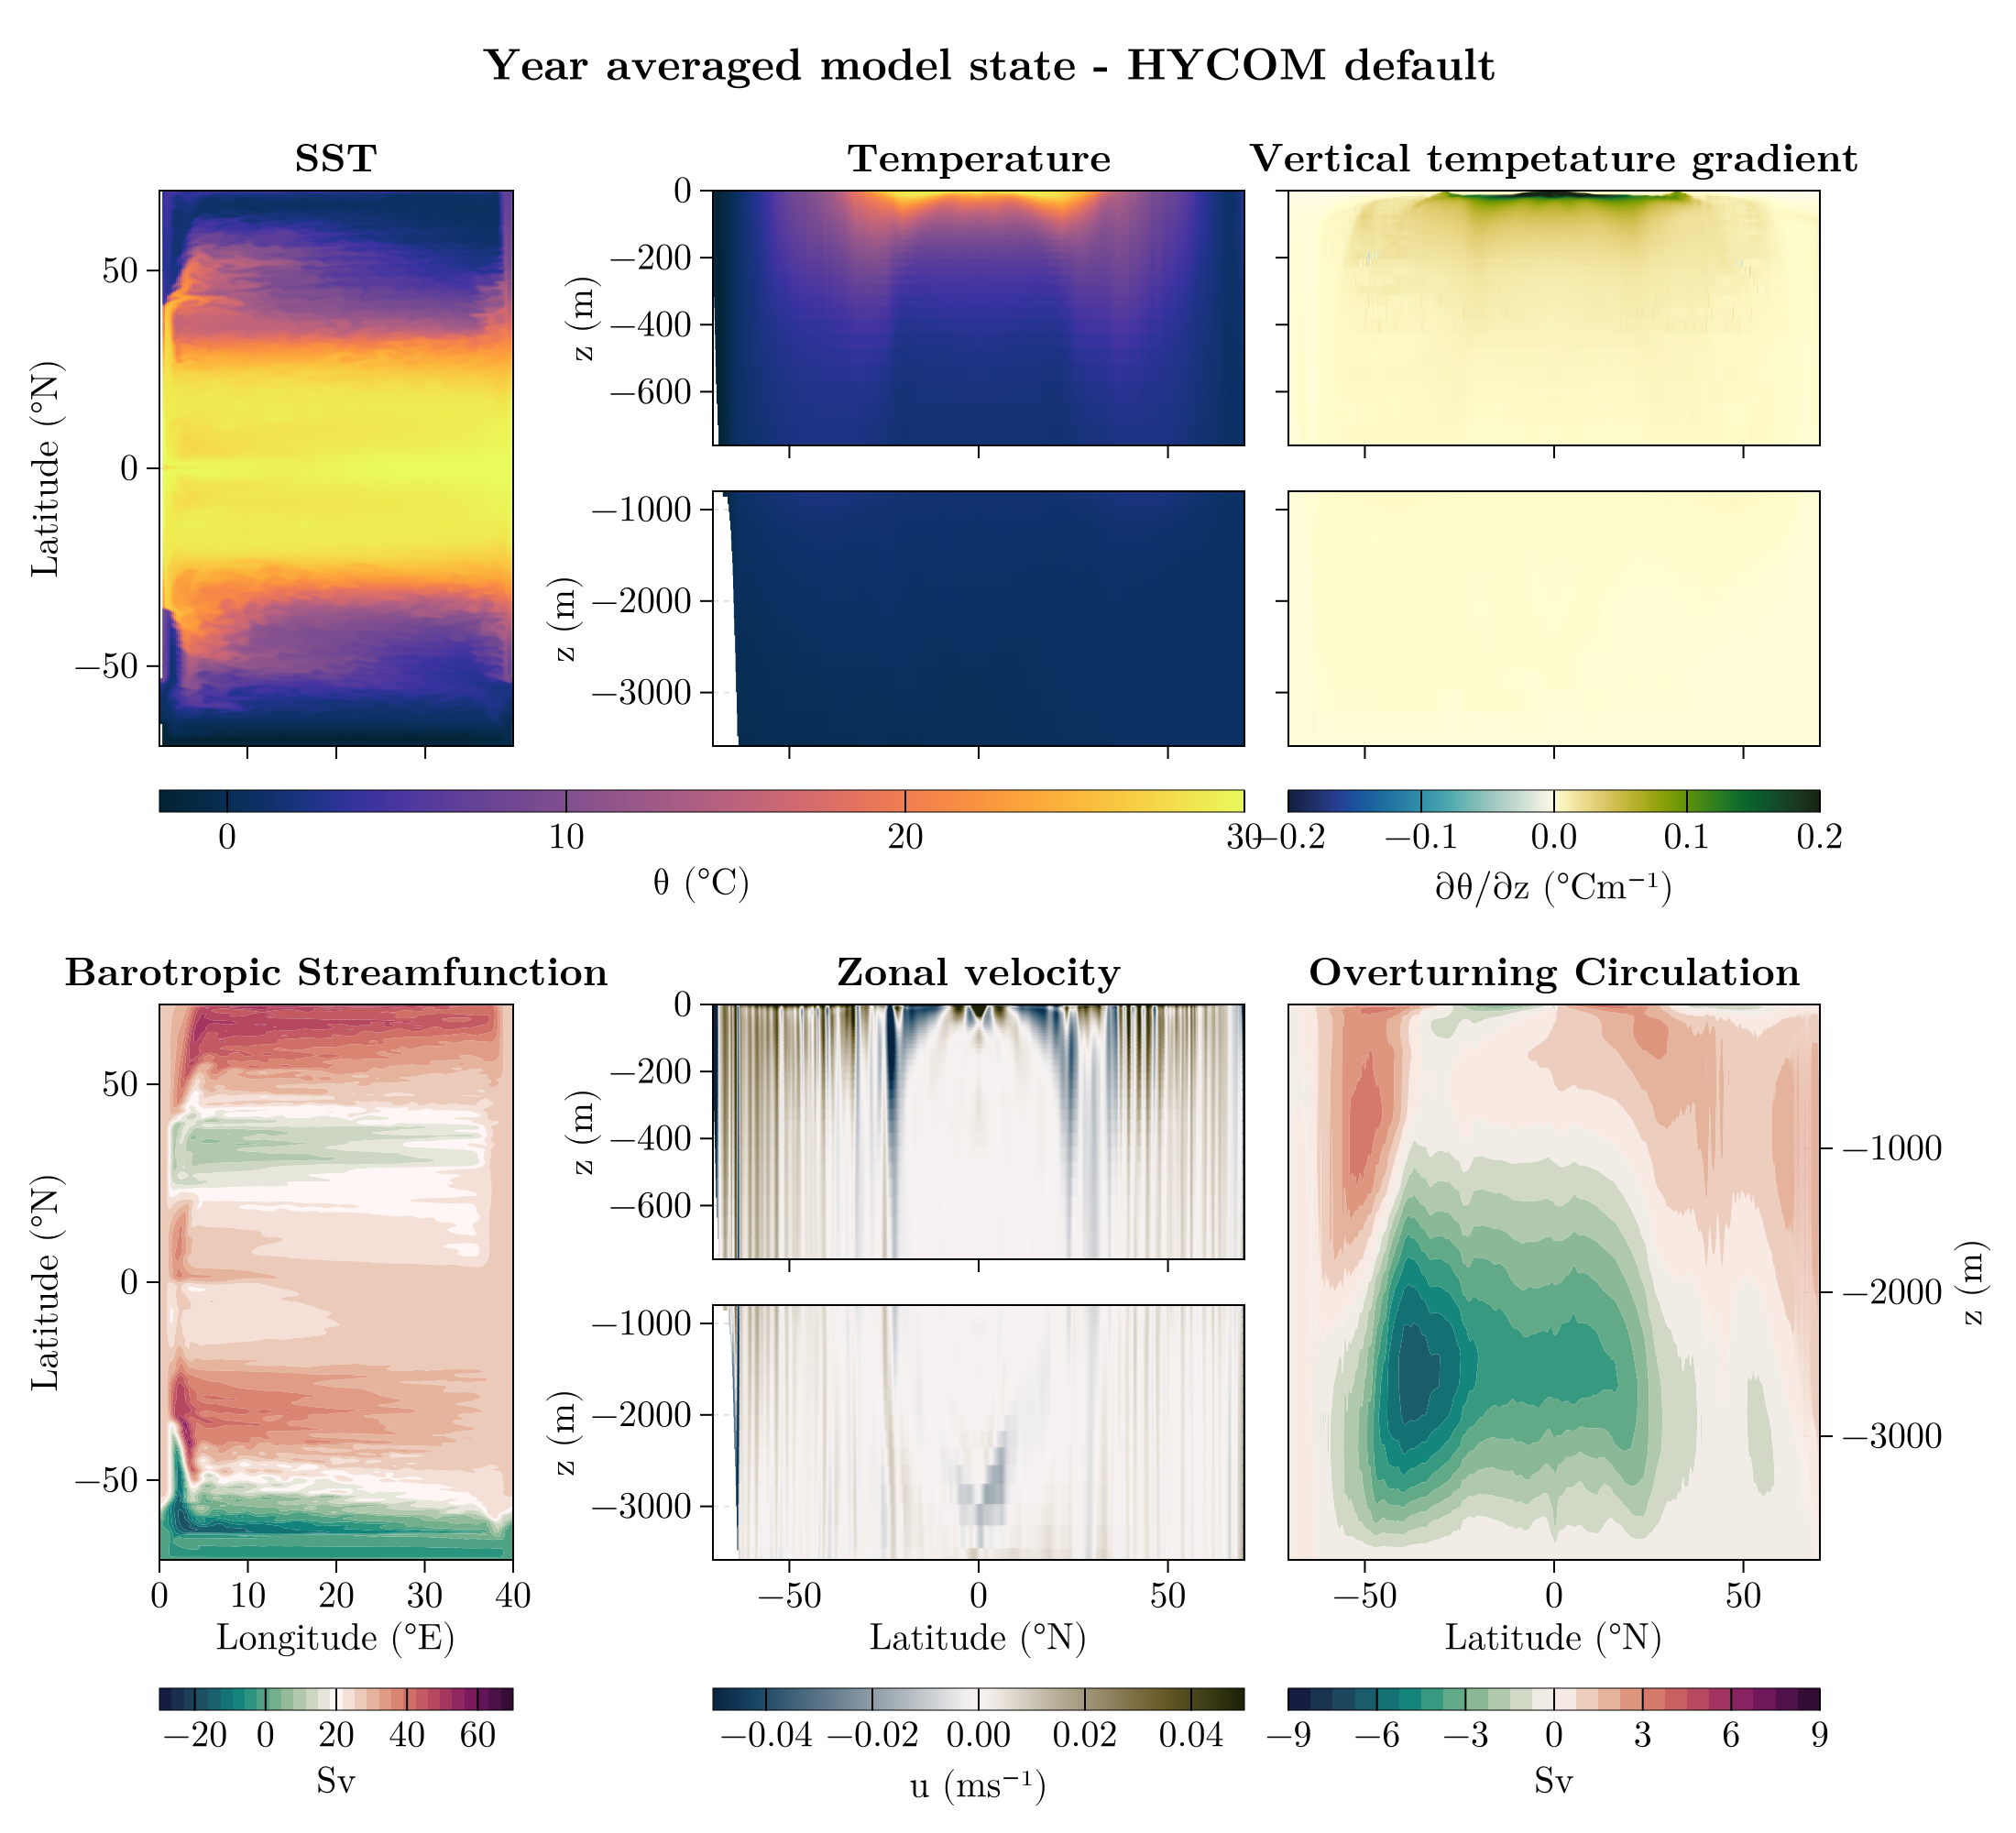

In [42]:
fig = Figure(size = (1100, 1000))

ax_sst = Axis(fig[1:2, 1], xlabel = "Longitude (°E)", ylabel = "Latitude (°N)", title = "SST")
xlims!(ax_sst, hy_d_crs.lonh[1], hy_d_crs.lonh[end])
hidexdecorations!(ax_sst, ticks = false)
hm = heatmap!(ax_sst, hy_d_crs.lonh, hy_d_crs.lath, hy_d_sst, colorrange = θcrange, colormap = :thermal)

top = 1:55
bot = top[end]+1:74

axtop = Axis(fig[1, 2], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Temperature")
hm = heatmap!(axtop, hy_d_crs.lath, hy_d_crs.zl[top], hy_d_tzm[:, top], colorrange = θcrange, colormap = :thermal)
axbot = Axis(fig[2, 2], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, hy_d_crs.lath, hy_d_crs.zl[bot], hy_d_tzm[:, bot], colorrange = θcrange, colormap = :thermal)
ylims!(axbot, hy_d_crs.zl[bot[end]], hy_d_crs.zl[bot[1]])
Colorbar(fig[3, 1:2], hm, vertical = false, flipaxis = false, label = "θ (°C)")

hidexdecorations!(axtop, ticks = false)
hidexdecorations!(axbot, ticks = false)

axtop = Axis(fig[1, 3], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Vertical tempetature gradient")
hm = heatmap!(axtop, hy_d_crs.lath, hy_d_crs.zl[top], hy_d_dθ[:, top]; colorrange = dθcrange, colormap = :delta)
axbot = Axis(fig[2, 3], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, hy_d_crs.lath, hy_d_crs.zl[bot], hy_d_dθ[:, bot]; colorrange = dθcrange, colormap = :delta)
ylims!(axbot, hy_d_crs.zl[bot[end]], hy_d_crs.zl[bot[1]])
Colorbar(fig[3, 3], hm, vertical = false, flipaxis = false, label = "∂θ/∂z (°Cm⁻¹)")

hidexdecorations!(axtop, ticks = false)
hidexdecorations!(axbot, ticks = false)
hideydecorations!(axtop, ticks = false)
hideydecorations!(axbot, ticks = false)

ax_ψb = Axis(fig[4:5, 1], xlabel = "Longitude (°E)", ylabel = "Latitude (°N)", title = "Barotropic Streamfunction")
xlims!(ax_ψb, hy_d_crs.lonq[1], hy_d_crs.lonq[end])
ylims!(ax_ψb, hy_d_crs.lath[1], hy_d_crs.lath[end])
cf = contourf!(ax_ψb, hy_d_crs.lonq, hy_d_crs.lath, hy_d_ψb[:, :, 1], colormap = :curl, levels = ψbcrange)
Colorbar(fig[6, 1], cf, vertical = false, flipaxis = false, label = "Sv")

# linkxaxes!(ax_sst, ax_ψb)

axtop = Axis(fig[4, 2], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Zonal velocity")
hm = heatmap!(axtop, hy_d_crs.lath, hy_d_crs.zl[top], hy_d_uzm[:, top]; colorrange = ucrange, colormap = :diff)
axbot = Axis(fig[5, 2], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, hy_d_crs.lath, hy_d_crs.zl[bot], hy_d_uzm[:, bot]; colorrange = ucrange, colormap = :diff)
ylims!(axbot, hy_d_crs.zl[bot[end]], hy_d_crs.zl[bot[1]])
Colorbar(fig[6, 2], hm, vertical = false, flipaxis = false, label = "u (ms⁻¹)")

hidexdecorations!(axtop, ticks = false)

#  depth-latitude
ax_ψo = Axis(fig[4:5, 3], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Overturning Circulation",
             yaxisposition = :right)
cf = contourf!(ax_ψo, hy_d_crs.latq, hy_d_crs.zl, hy_d_ψo[1, :, :, 1], colormap = :curl, levels = ψocrange)
Colorbar(fig[6, 3], cf, vertical = false, flipaxis = false, label = "Sv")
xlims!(ax_ψo, hy_d_crs.latq[1], hy_d_crs.latq[end])
ylims!(ax_ψo, hy_d_crs.zl[end], hy_d_crs.zl[1])

colsize!(fig.layout, 1, Relative(1/4))

Label(fig[0, :], "Year averaged model state - HYCOM default", fontsize = 24, font = :bold)

fig

In [11]:
save("modelstate_hycom_native.png", fig)

## HYCOM `dz=3m`

In [43]:
hy_dz3_key = "hycom-dz3-PPMH3"

hy_dz3_monthly = catalogue[hy_dz3_key]["monthly"]
hy_dz3_monthlyrho2 = catalogue[hy_dz3_key]["monthlyrho2"]
hy_dz3_monthlyz = catalogue[hy_dz3_key]["monthlyz"]
hy_dz3_static = catalogue[hy_dz3_key]["static"]
hy_dz3_vc = catalogue[hy_dz3_key]["vc"]

hy_dz3_crs = get_geo_coords(hy_dz3_static, hy_dz3_vc)

ds = NCDataset(hy_dz3_monthlyz, maskingvalue = NaN)

hy_dz3_sst = mean(ds["thetao"][:, :, 1, :], dims = 4)[:, :, 1, 1]
hy_dz3_tzm = mean(nanmean(ds["thetao"][:, :, :, :], dims = 1), dims = 4)[1, :, :, 1]
hy_dz3_uzm = nanmean(ds["uo"][:, :, :, :], dims = (1, 4))
hy_dz3_uzm = dropdims(hy_dz3_uzm, dims = (1, 4))
hy_dz3_zl = -ds["z_l"][:]

close(ds)

hy_dz3_ψb = barotropic_streamfunction(hy_dz3_monthly)

hy_dz3_ρolayer, hy_dz3_ψo = overturning_circulation(hy_dz3_monthlyz, "z_l")

hy_dz3_dθ = dθ_dz(hy_dz3_monthly)
hy_dz3_dθ = dropdims(hy_dz3_dθ, dims = (1, 4))
nothing

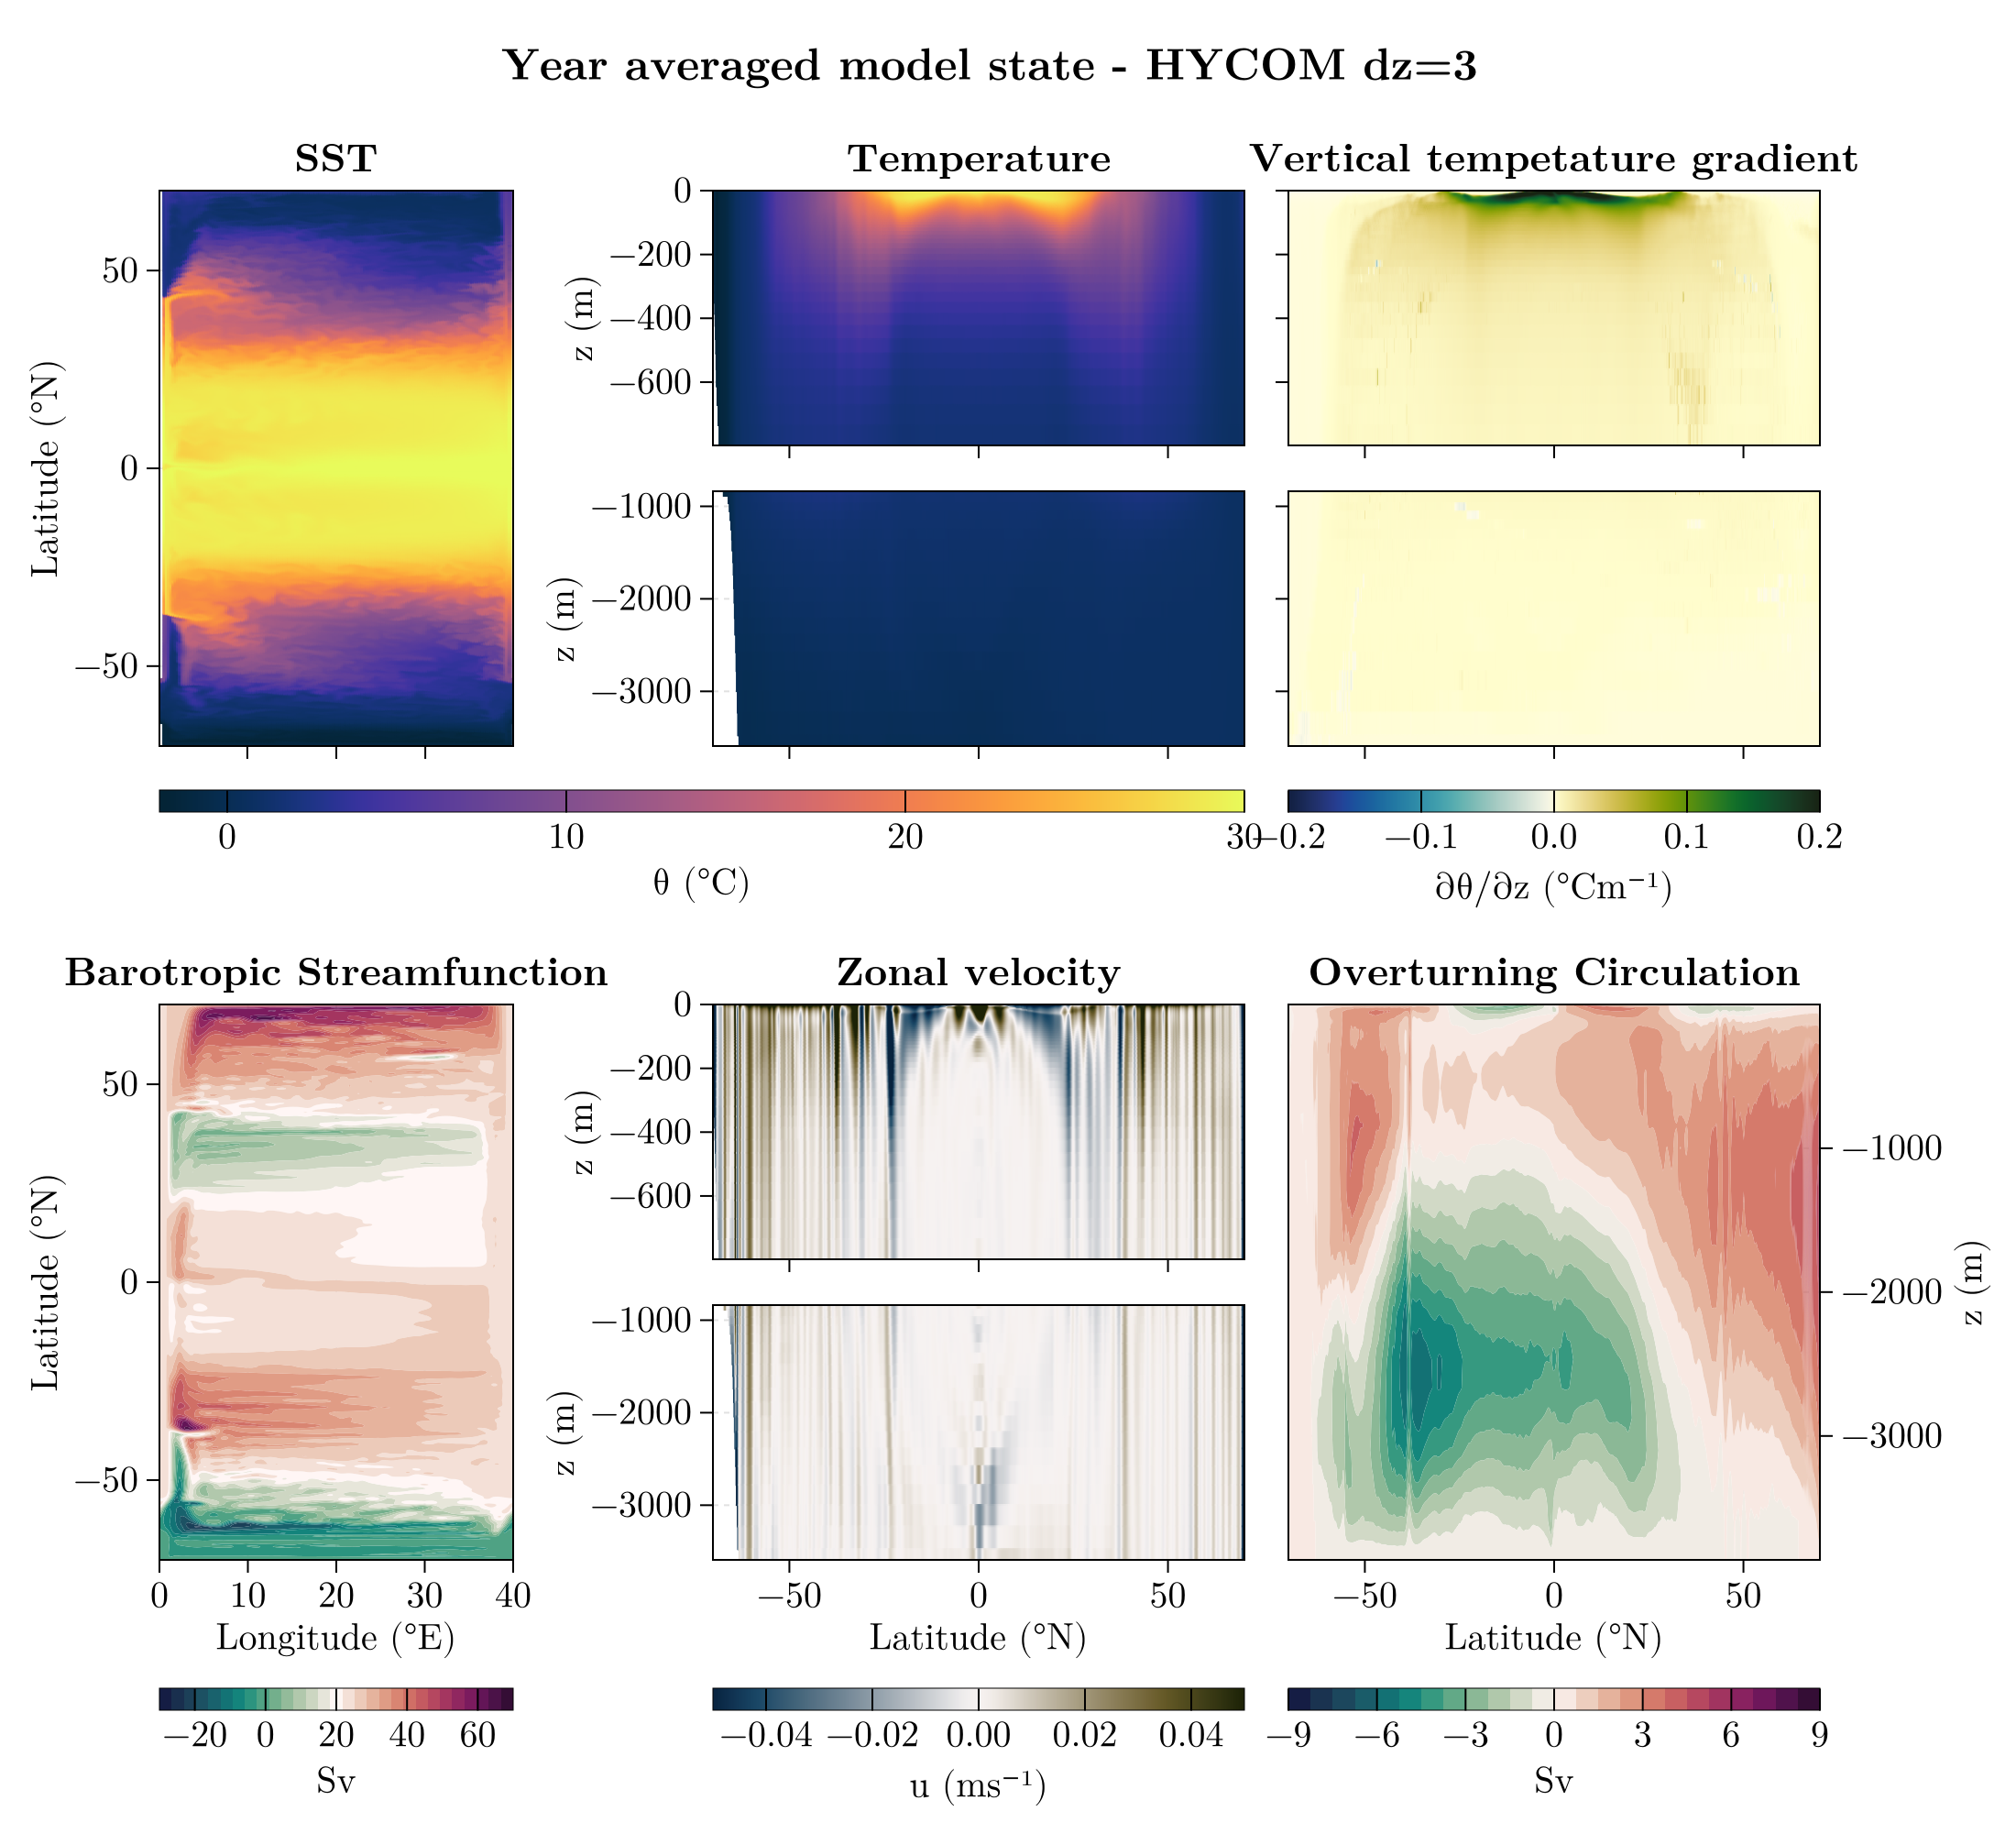

In [44]:
fig = Figure(size = (1100, 1000))

ax_sst = Axis(fig[1:2, 1], xlabel = "Longitude (°E)", ylabel = "Latitude (°N)", title = "SST")
xlims!(ax_sst, hy_dz3_crs.lonh[1], hy_dz3_crs.lonh[end])
hidexdecorations!(ax_sst, ticks = false)
hm = heatmap!(ax_sst, hy_dz3_crs.lonh, hy_dz3_crs.lath, hy_dz3_sst, colorrange = θcrange, colormap = :thermal)

top = 1:55
bot = top[end]+1:74

axtop = Axis(fig[1, 2], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Temperature")
hm = heatmap!(axtop, hy_dz3_crs.lath, zl[top], hy_dz3_tzm[:, top], colorrange = θcrange, colormap = :thermal)
axbot = Axis(fig[2, 2], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, hy_dz3_crs.lath, hy_dz3_zl[bot], hy_dz3_tzm[:, bot], colorrange = θcrange, colormap = :thermal)
ylims!(axbot, zl[bot[end]], zl[bot[1]])
Colorbar(fig[3, 1:2], hm, vertical = false, flipaxis = false, label = "θ (°C)")

hidexdecorations!(axtop, ticks = false)
hidexdecorations!(axbot, ticks = false)

axtop = Axis(fig[1, 3], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Vertical tempetature gradient")
hm = heatmap!(axtop, hy_dz3_crs.lath, hy_dz3_zl[top], hy_dz3_dθ[:, top]; colorrange = dθcrange, colormap = :delta)
axbot = Axis(fig[2, 3], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, hy_dz3_crs.lath, hy_dz3_zl[bot], hy_dz3_dθ[:, bot]; colorrange = dθcrange, colormap = :delta)
ylims!(axbot, hy_dz3_zl[bot[end]], hy_dz3_zl[bot[1]])
Colorbar(fig[3, 3], hm, vertical = false, flipaxis = false, label = "∂θ/∂z (°Cm⁻¹)")

hidexdecorations!(axtop, ticks = false)
hidexdecorations!(axbot, ticks = false)
hideydecorations!(axtop, ticks = false)
hideydecorations!(axbot, ticks = false)

ax_ψb = Axis(fig[4:5, 1], xlabel = "Longitude (°E)", ylabel = "Latitude (°N)", title = "Barotropic Streamfunction")
xlims!(ax_ψb, hy_dz3_crs.lonq[1], hy_dz3_crs.lonq[end])
ylims!(ax_ψb, hy_dz3_crs.lath[1], hy_dz3_crs.lath[end])
cf = contourf!(ax_ψb, hy_dz3_crs.lonq, hy_dz3_crs.lath, hy_dz3_ψb[:, :, 1], colormap = :curl, levels = ψbcrange)
Colorbar(fig[6, 1], cf, vertical = false, flipaxis = false, label = "Sv")

# linkxaxes!(ax_sst, ax_ψb)

axtop = Axis(fig[4, 2], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Zonal velocity")
hm = heatmap!(axtop, hy_dz3_crs.lath, hy_dz3_zl[top], hy_dz3_uzm[:, top]; colorrange = ucrange, colormap = :diff)
axbot = Axis(fig[5, 2], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, hy_dz3_crs.lath, hy_dz3_zl[bot], hy_dz3_uzm[:, bot]; colorrange = ucrange, colormap = :diff)
ylims!(axbot, hy_dz3_zl[bot[end]], hy_dz3_zl[bot[1]])
Colorbar(fig[6, 2], hm, vertical = false, flipaxis = false, label = "u (ms⁻¹)")

hidexdecorations!(axtop, ticks = false)

#  depth-latitude
ax_ψo = Axis(fig[4:5, 3], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Overturning Circulation",
             yaxisposition = :right)
cf = contourf!(ax_ψo, hy_dz3_crs.latq, hy_dz3_zl, hy_dz3_ψo[1, :, :, 1], colormap = :curl, levels = ψocrange)
Colorbar(fig[6, 3], cf, vertical = false, flipaxis = false, label = "Sv")
xlims!(ax_ψo, hy_dz3_crs.latq[1], hy_dz3_crs.latq[end])
ylims!(ax_ψo, hy_dz3_zl[end], hy_dz3_zl[1])

colsize!(fig.layout, 1, Relative(1/4))

Label(fig[0, :], "Year averaged model state - HYCOM dz=3", fontsize = 24, font = :bold)

fig

## Overturning in density-latitude space

In [45]:
zs_layer, zs_ψo = overturning_circulation(zs_monthlyrho2, "rho2_l")
hy_d_layer, hy_d_ψo = overturning_circulation(hy_d_monthlyrho2, "rho2_l")
hy_dz3_layer, hy_dz3_ψo = overturning_circulation(hy_dz3_monthlyrho2, "rho2_l")
nothing

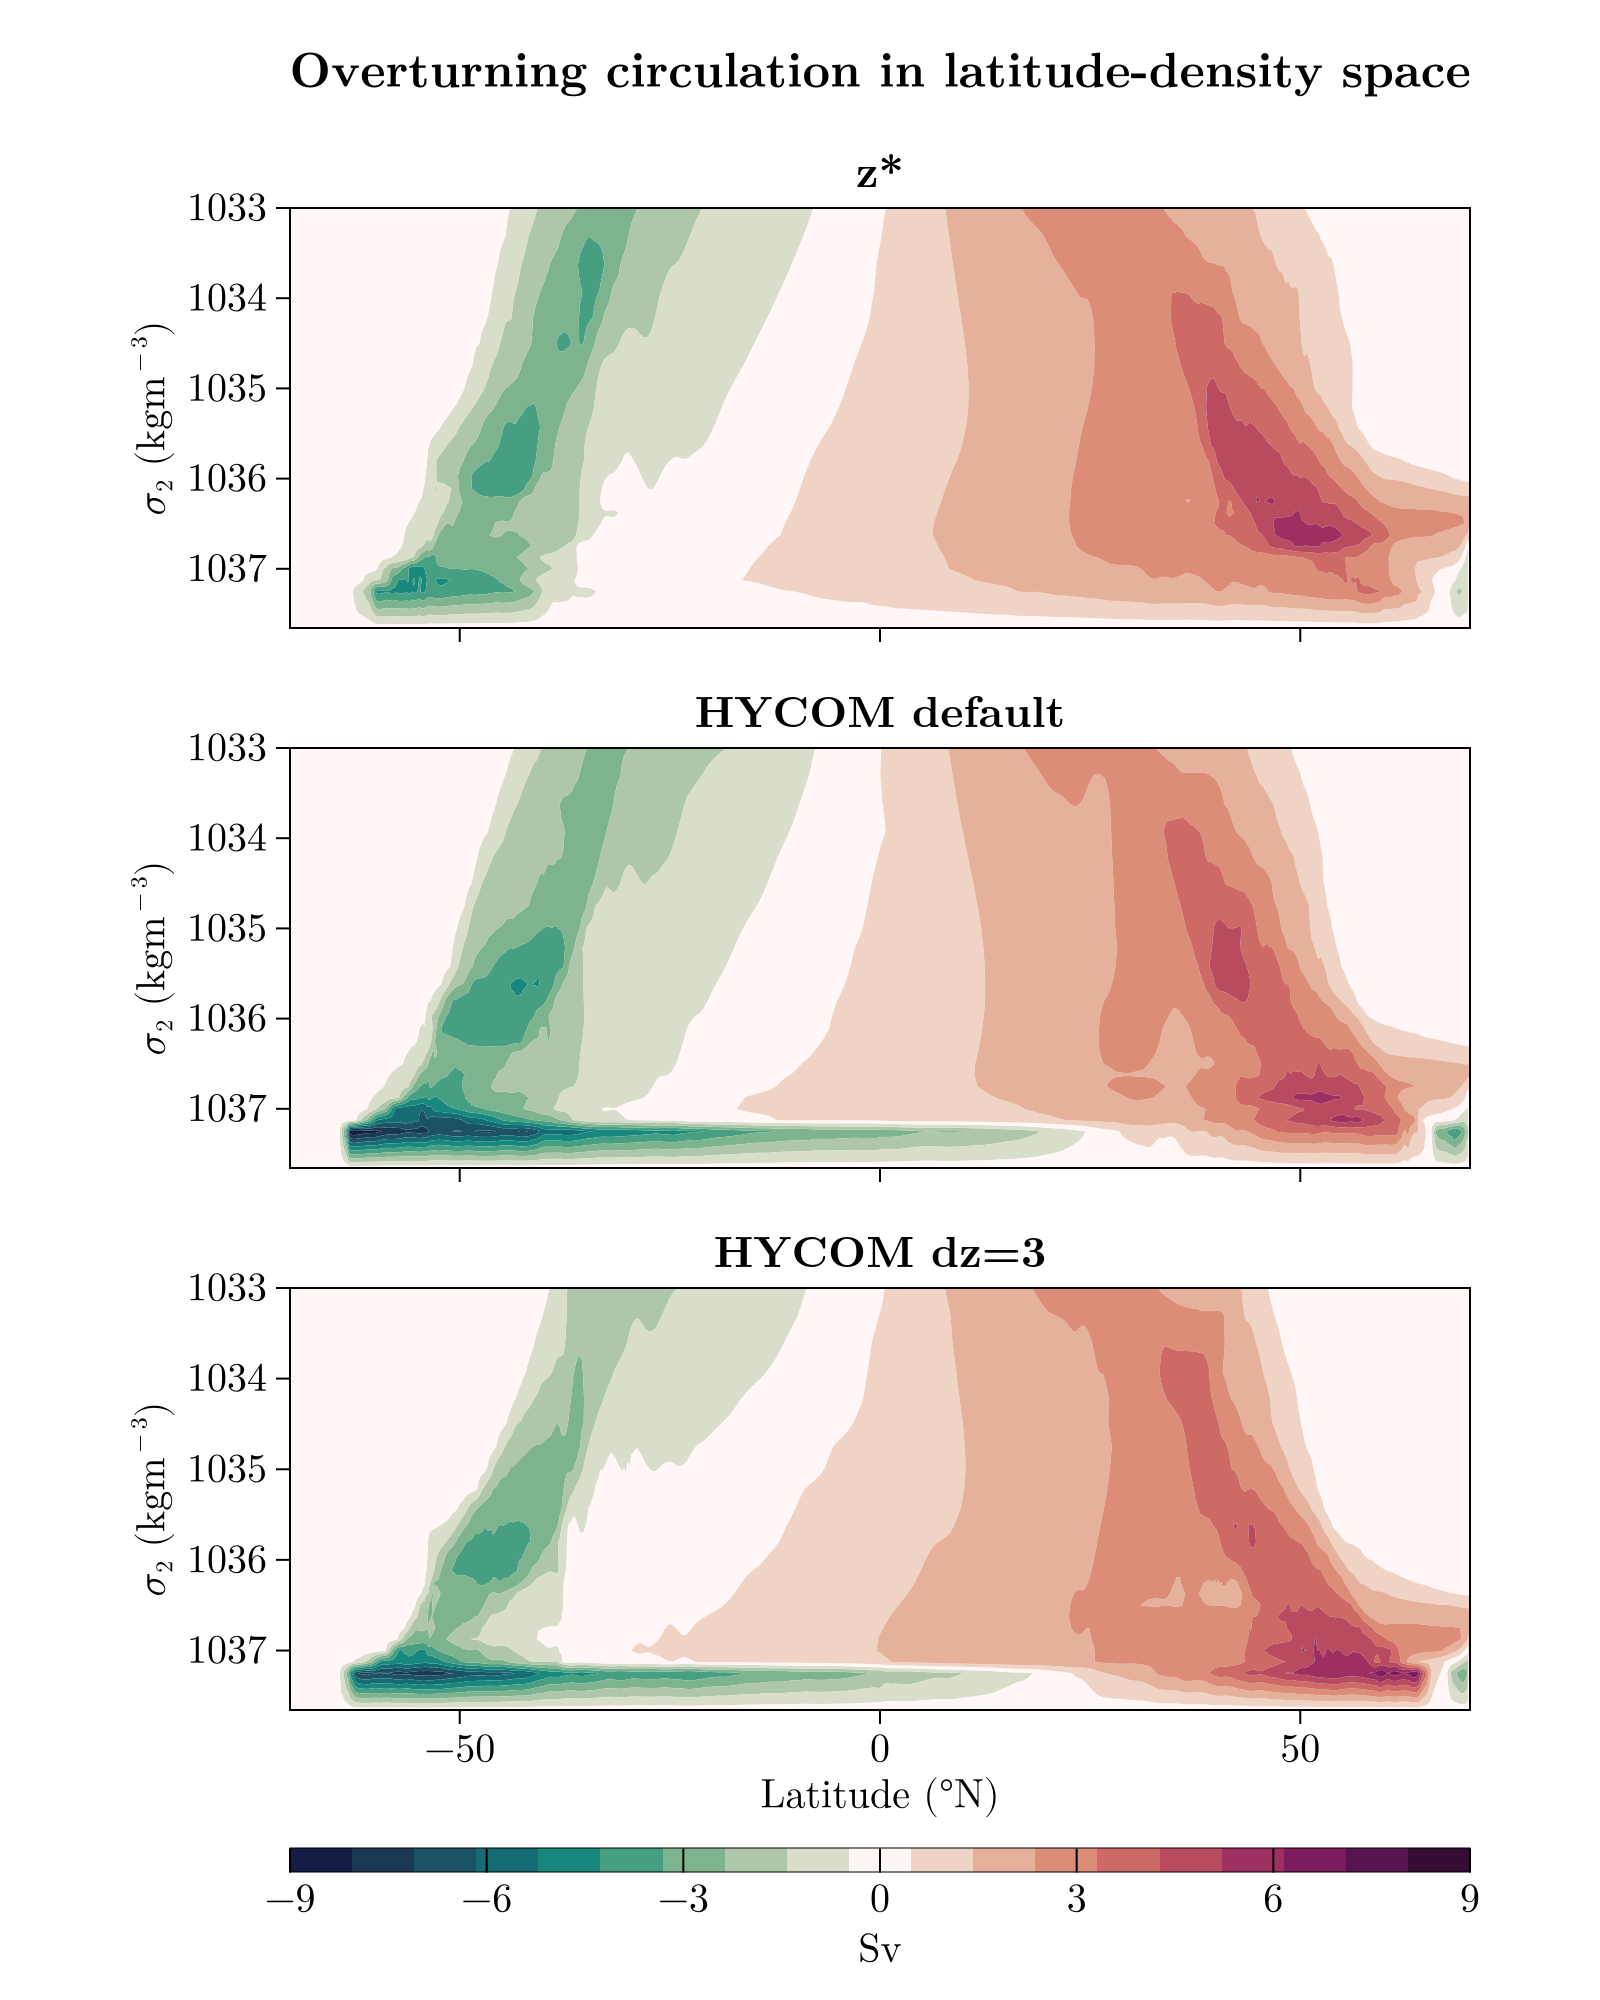

In [47]:
fig = Figure(size = (800, 1000))

ax_ψo_zs = Axis(fig[1, 1], xlabel = "Latitude (°N)", ylabel = L"$σ_{2}$ (kgm$^{-3}$)", title = "z*")
cf = contourf!(ax_ψo_zs, zs_crs.latq, zs_layer, zs_ψo[1, :, :, 1], colormap = :curl, levels = ψocrange)
hidexdecorations!(ax_ψo_zs, ticks = false)
xlims!(ax_ψo_zs, zs_crs.latq[1], zs_crs.latq[end])
ylims!(ax_ψo_zs, zs_layer[end], 1033)
ax_ψo_zs.yreversed = true

ax_ψo_hy = Axis(fig[2, 1], xlabel = "Latitude (°N)", ylabel = L"$σ_{2}$ (kgm$^{-3}$)", title = "HYCOM default")
cf = contourf!(ax_ψo_hy, hy_d_crs.latq, hy_d_layer, hy_d_ψo[1, :, :, 1], colormap = :curl, levels = ψocrange)
hidexdecorations!(ax_ψo_hy, ticks = false)
xlims!(ax_ψo_hy, hy_d_crs.latq[1], hy_d_crs.latq[end])
ylims!(ax_ψo_hy, hy_d_layer[end], 1033)
ax_ψo_hy.yreversed = true

ax_ψo_hydz3 = Axis(fig[3, 1], xlabel = "Latitude (°N)", ylabel = L"$σ_{2}$ (kgm$^{-3}$)", title = "HYCOM dz=3")
cf = contourf!(ax_ψo_hydz3, hy_dz3_crs.latq, hy_dz3_layer, hy_dz3_ψo[1, :, :, 1], colormap = :curl, levels = ψocrange)
xlims!(ax_ψo_hydz3, hy_dz3_crs.latq[1], hy_dz3_crs.latq[end])
ylims!(ax_ψo_hydz3, hy_dz3_layer[end], 1033)
ax_ψo_hydz3.yreversed = true

Label(fig[0, :], "Overturning circulation in latitude-density space", fontsize = 24, font = :bold)
Colorbar(fig[4, :], cf, vertical = false, flipaxis = false, label = "Sv")
fig